1.1 Convolution rom scratch

#Notes
#idea is what is convolutinoal

greyscale * kernal/filter---area filtering--->new value
blur with averging 10 1000 10 10 10.. -> 20 avg

kernel not flip --> cross-correlation
zero padding for fullfill the whole area ex 3*3 with 5*5 filter


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [48]:
def convolve_four_loops(image, kernel):
    #flip filter
    kernel = np.flip(kernel, axis=(0, 1))

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    #zero padding to handle borders
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

    #init
    output = np.zeros_like(image, dtype=float)

    #four layers

    #i j is for the image
    #m n is for the kernel
    for i in range(image_height):
        for j in range(image_width):
            for m in range(kernel_height):
                for n in range(kernel_width):
                    output[i, j] += padded_image[i + m, j + n] * kernel[m, n]

    return output

In [49]:
def convolve_two_loops(image, kernel):
    #flip filter
    kernel = np.flip(kernel, axis=(0, 1))

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    #zero padding
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

    output = np.zeros_like(image, dtype=float)

    for i in range(image_height):
        for j in range(image_width):
            region = padded_image[i:i + kernel_height, j:j + kernel_width]
            region_kernel = region * kernel
            value = np.sum(region_kernel)
            output[i, j] = value

    return output

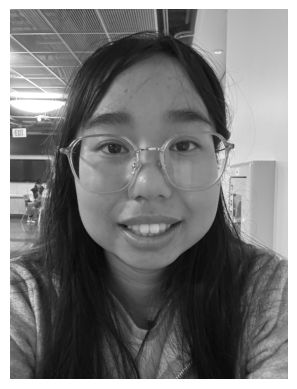

In [54]:
image = plt.imread("/Users/lorrainnnn/Lorrainnn.github.io/2/data/my_photo.jpg")

#convert to grayscale
gray_image = np.mean(image[:, :, :3], axis=2)

plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.show() 

In [55]:
box_filter = np.ones((9, 9)) / 81

Dx = np.array([[1, 0, -1]])

Dy = np.array([[1],
               [0],
               [-1]])

blurred_image = convolve_two_loops(gray_image, box_filter)
#dx dy gradient images
dx_image = convolve_two_loops(gray_image, Dx)
dy_image = convolve_two_loops(gray_image, Dy)

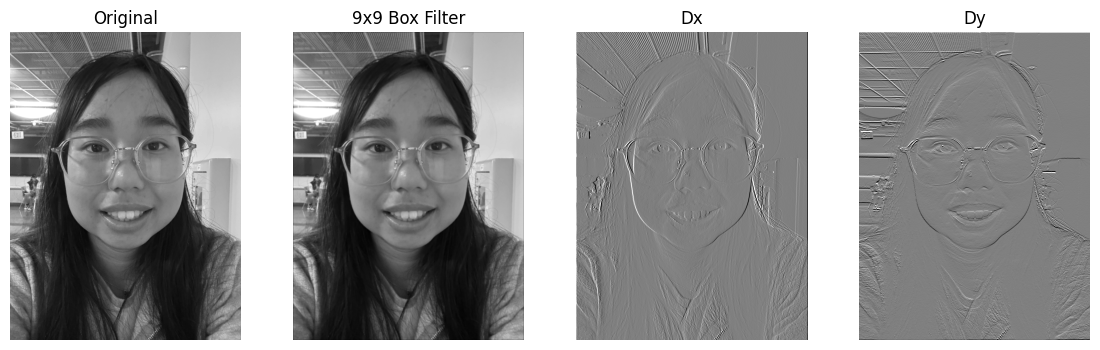

In [ ]:
#These 2 used for improve the general contrast
# i found directly abs 's img is not that obvious
dx_limit = np.percentile(np.abs(dx_image), 99)
dy_limit = np.percentile(np.abs(dy_image), 99)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(blurred_image, cmap="gray")
plt.title("9x9 Box Filter")
plt.axis("off")


plt.subplot(1, 4, 3)
#make edge more visible
plt.imshow(dx_image, cmap="gray", vmin=-dx_limit, vmax=dx_limit)
plt.title("Dx")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(dy_image, cmap="gray", vmin=-dy_limit, vmax=dy_limit)
plt.title("Dy")
plt.axis("off")

plt.show()

In [ ]:
from scipy.signal import convolve2d
import time

start = time.time()
result_4 = convolve_four_loops(gray_image, box_filter)
four_loops_time = time.time() - start

start = time.time()
result_2 = convolve_two_loops(gray_image, box_filter)
two_loops_time = time.time() - start

start = time.time()
result_scipy = convolve2d(gray_image, box_filter, mode="same", boundary="fill", fillvalue=0)
scipy_time = time.time() - start

print("Four loops:", four_loops_time)
print("Two loops:", two_loops_time)
print("Scipy:", scipy_time)


Four loops: 115.31692290306091
Two loops: 11.397273063659668
Scipy: 0.4912407398223877


#part 1.2

In [ ]:
cameraman = plt.imread("/Users/lorrainnnn/Lorrainnn.github.io/2/data/cameraman.png")

#convert to grayscale
cameraman = np.mean(cameraman[:, :, :3], axis=2)

#same filter
Dx = np.array([[1, 0, -1]])

Dy = np.array([[1],
               [0],
               [-1]])

#vertical edge
dx = convolve2d(cameraman, Dx, mode="same", boundary="fill", fillvalue=0)
#horizontal edge
dy = convolve2d(cameraman, Dy, mode="same", boundary="fill", fillvalue=0)

In [ ]:
#confirm on whether it's grayscale
#print(cameraman.shape)

#it still has four channels, not just greyscale photo

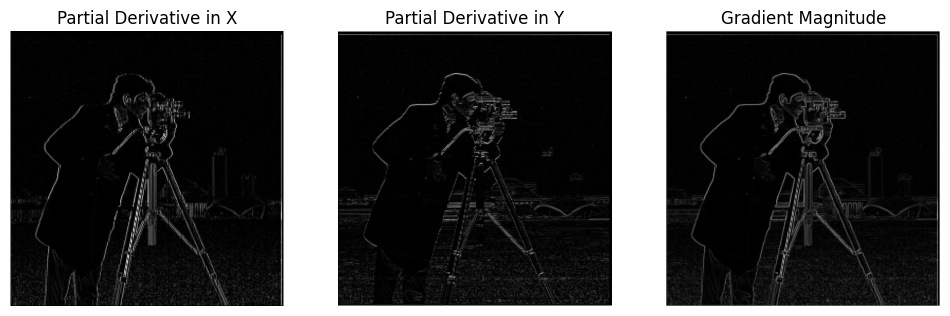

In [ ]:
#gradient magnitude calculation(mathmatics)
gradient_magnitude = np.sqrt(dx ** 2 + dy ** 2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(dx), cmap="gray")
plt.title("Partial Derivative in X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(dy), cmap="gray")
plt.title("Partial Derivative in Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()


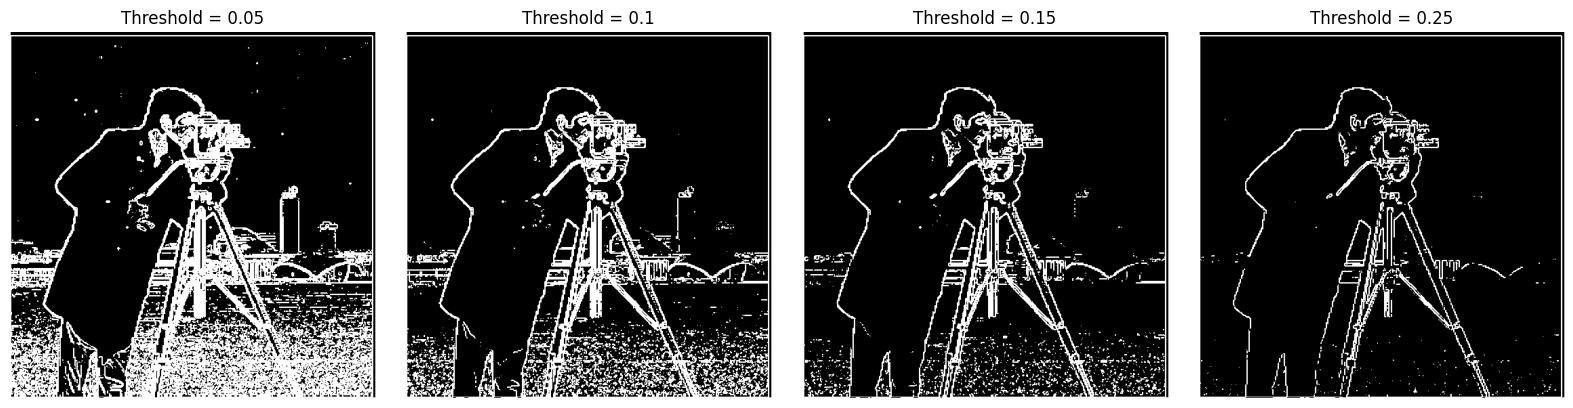

In [ ]:
#test on different thresholds
thresholds = [0.05, 0.10, 0.15, 0.25]

plt.figure(figsize=(16, 4))

for i, threshold in enumerate(thresholds):
    edge_image = gradient_magnitude > threshold

    plt.subplot(1, 4, i + 1)
    plt.imshow(edge_image, cmap="gray")
    plt.title("Threshold = " + str(threshold))
    plt.axis("off")

plt.tight_layout()
plt.show()

basically the result is still noisy -> why we need aussian smoothing later

#1.3 Derivative of Gaussian (DoG) Filter

In [ ]:
#%pip install opencv-python
import cv2


     |████████████████████████████████| 48.3 MB 17.0 MB/s eta 0:00:01
You should consider upgrading via the '/Users/lorrainnnn/Lorrainnn.github.io/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


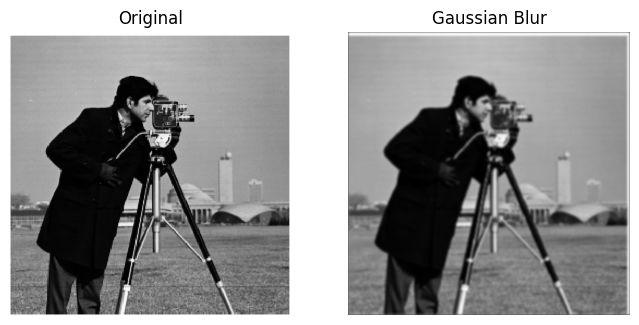

In [ ]:
#apply Gaussian filter to the image
# -> smooth the image to reduce noise and improve edge detection

#kernel size 9, 2D gaussian sd = 2
gaussian_1d = cv2.getGaussianKernel(9, 2)
gaussian_filter = gaussian_1d @ gaussian_1d.T

blurred_cameraman = convolve2d(
    cameraman,
    gaussian_filter,
    mode="same",
    boundary="fill",
    fillvalue=0
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(cameraman, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_cameraman, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

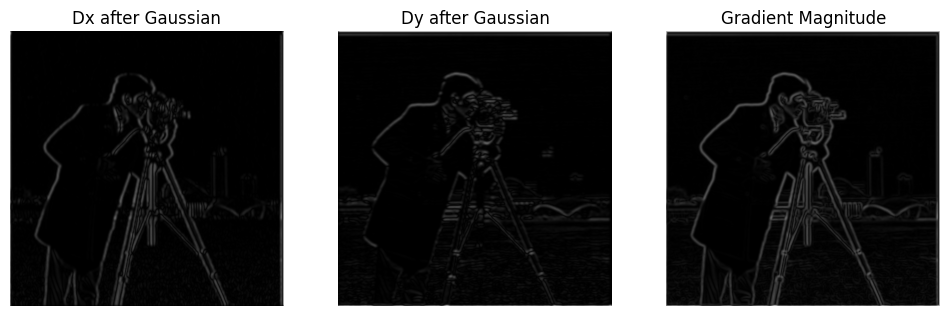

In [ ]:
#
blur_dx = convolve2d(blurred_cameraman, Dx, mode="same", boundary="fill", fillvalue=0)
blur_dy = convolve2d(blurred_cameraman, Dy, mode="same", boundary="fill", fillvalue=0)

blur_gradient = np.sqrt(blur_dx ** 2 + blur_dy ** 2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(blur_dx), cmap="gray")
plt.title("Dx after Gaussian")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(blur_dy), cmap="gray")
plt.title("Dy after Gaussian")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_gradient, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()

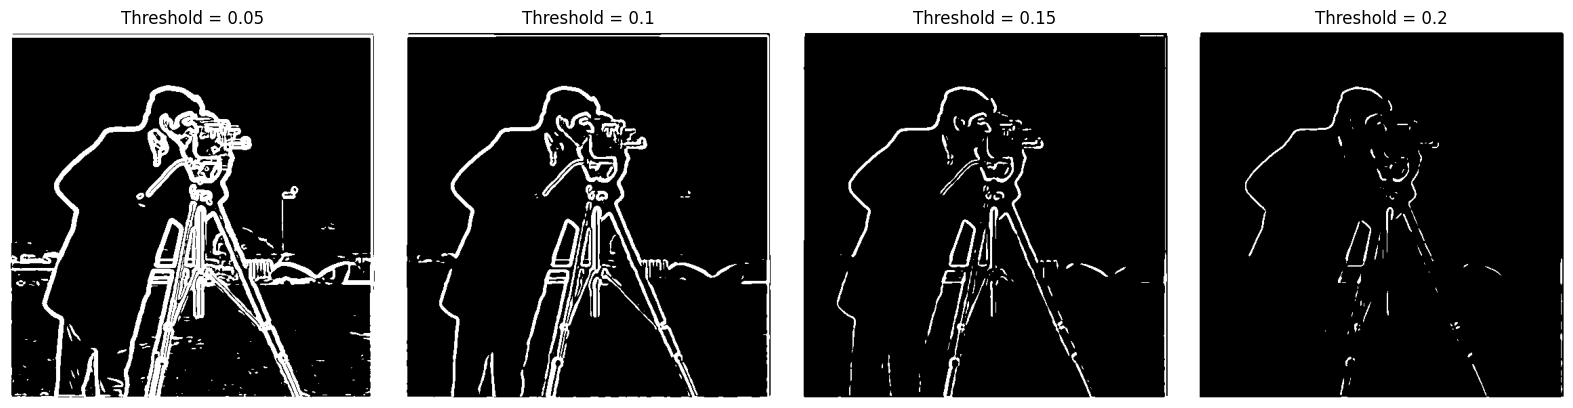

In [ ]:
#the point of threshold is basically to determine which pixels are considered edges based on the gradient magnitude. A lower threshold will result in more edges being detected, while a higher threshold will result in fewer edges being detected.
thresholds = [0.05, 0.10, 0.15, 0.2]

plt.figure(figsize=(16, 4))

for i, threshold in enumerate(thresholds):
    #if larger means edges considered
    edge_image = blur_gradient > threshold

    plt.subplot(1, 4, i + 1)
    plt.imshow(edge_image, cmap="gray")
    plt.title("Threshold = " + str(threshold))
    plt.axis("off")

plt.tight_layout()
plt.show()

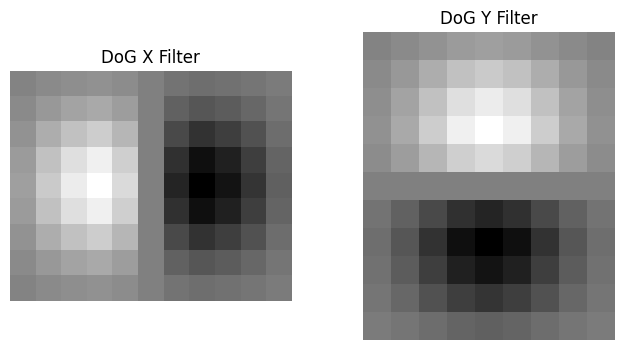

In [37]:
DoG_x = convolve2d(gaussian_filter, Dx, mode="full")
DoG_y = convolve2d(gaussian_filter, Dy, mode="full")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(DoG_x, cmap="gray")
plt.title("DoG X Filter")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(DoG_y, cmap="gray")
plt.title("DoG Y Filter")
plt.axis("off")

plt.show()

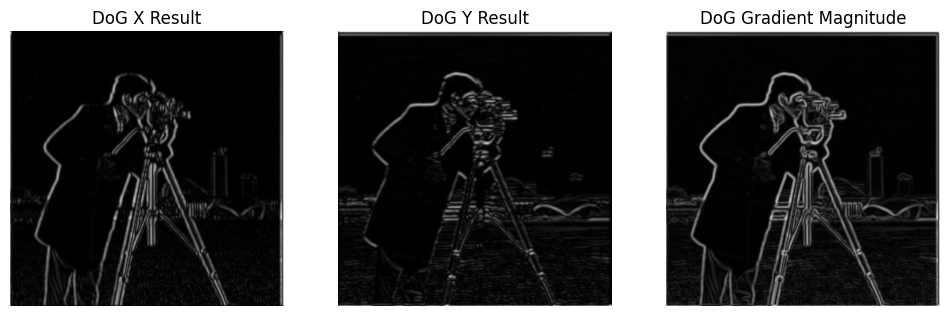

In [ ]:
#apply DoG filters to the original image
dog_dx = convolve2d(cameraman, DoG_x, mode="same", boundary="fill", fillvalue=0)
dog_dy = convolve2d(cameraman, DoG_y, mode="same", boundary="fill", fillvalue=0)

dog_gradient = np.sqrt(dog_dx ** 2 + dog_dy ** 2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(dog_dx), cmap="gray")
plt.title("DoG X Result")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(dog_dy), cmap="gray")
plt.title("DoG Y Result")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dog_gradient, cmap="gray")
plt.title("DoG Gradient Magnitude")
plt.axis("off")

plt.show()

In [ ]:
#check on img issue
#print("Gaussian then derivative:")
#print("min:", blur_gradient.min())
#print("max:", blur_gradient.max())

#print("\nDerivative of Gaussian:")
#print("min:", dog_gradient.min())
#print("max:", dog_gradient.max())


Gaussian then derivative:
min: 2.2352448537074976e-06
max: 0.7824325405910515

Derivative of Gaussian:
min: 2.235244853800693e-06
max: 0.38469738034543616


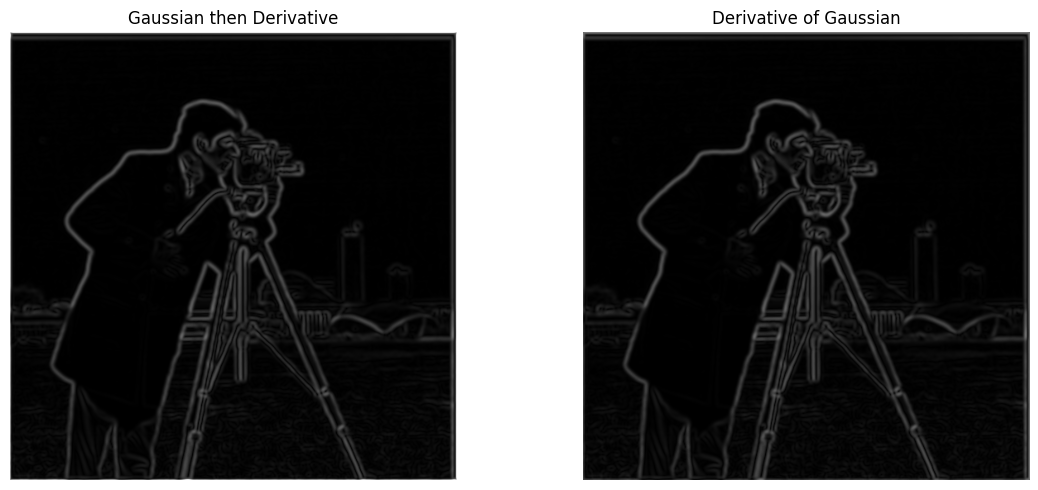

In [ ]:
#plt.imshow  plt.imshow() automatically 
# scales each image using its own minimum and maximum values. 
vmax = max(
    blur_gradient.max(),
    dog_gradient.max()
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    blur_gradient,
    cmap="gray",
    vmin=0,
    vmax=vmax
)
plt.title("Gaussian then Derivative")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    dog_gradient,
    cmap="gray",
    vmin=0,
    vmax=vmax
)
plt.title("Derivative of Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()

#Bell and Whistles: Gradient Orientation

use cyclic color to present direction
no use built-in angle function

magnitude <----> orientation

In [60]:
def atan_taylor(x, n_terms=50):
    result = np.zeros_like(x, dtype=float)

    for n in range(n_terms):
        result += ((-1) ** n) * x ** (2 * n + 1) / (2 * n + 1)

    return result


def gradient_orientation(gx, gy):
    a = np.abs(gx)
    b = np.abs(gy)

    c = np.sqrt(a ** 2 + b ** 2)

    t = np.zeros_like(c)
    valid = c > 0

    t[valid] = b[valid] / (c[valid] + a[valid])

    theta0 = 2 * atan_taylor(t)

    # exact vertical gradients
    vertical = (a == 0) & valid
    theta0[vertical] = np.pi / 2

    theta = theta0.copy()

    # quadrant II
    mask = (gx < 0) & (gy >= 0)
    theta[mask] = np.pi - theta0[mask]

    # quadrant III
    mask = (gx < 0) & (gy < 0)
    theta[mask] = np.pi + theta0[mask]

    # quadrant IV
    mask = (gx >= 0) & (gy < 0)
    theta[mask] = 2 * np.pi - theta0[mask]

    theta[~valid] = 0

    return theta


orientation = gradient_orientation(dx, dy)

In [61]:
from matplotlib.colors import hsv_to_rgb

hue = orientation / (2 * np.pi)
saturation = np.ones_like(hue)

mag_limit = np.percentile(gradient_magnitude, 99)
value = np.clip(gradient_magnitude / mag_limit, 0, 1)

hsv_image = np.stack([hue, saturation, value], axis=-1)
orientation_rgb = hsv_to_rgb(hsv_image)

In [63]:
# orientation color wheel
size = 300
coord = np.linspace(-1, 1, size)

xx, yy = np.meshgrid(coord, coord)
radius = np.sqrt(xx ** 2 + yy ** 2)

wheel_orientation = gradient_orientation(xx, yy)

wheel_hue = wheel_orientation / (2 * np.pi)
wheel_saturation = np.ones_like(wheel_hue)
wheel_value = np.ones_like(wheel_hue)

wheel_hsv = np.stack(
    [wheel_hue, wheel_saturation, wheel_value],
    axis=-1
)

wheel_rgb = hsv_to_rgb(wheel_hsv)

# make area outside the circle white
wheel_rgb[radius > 1] = 1

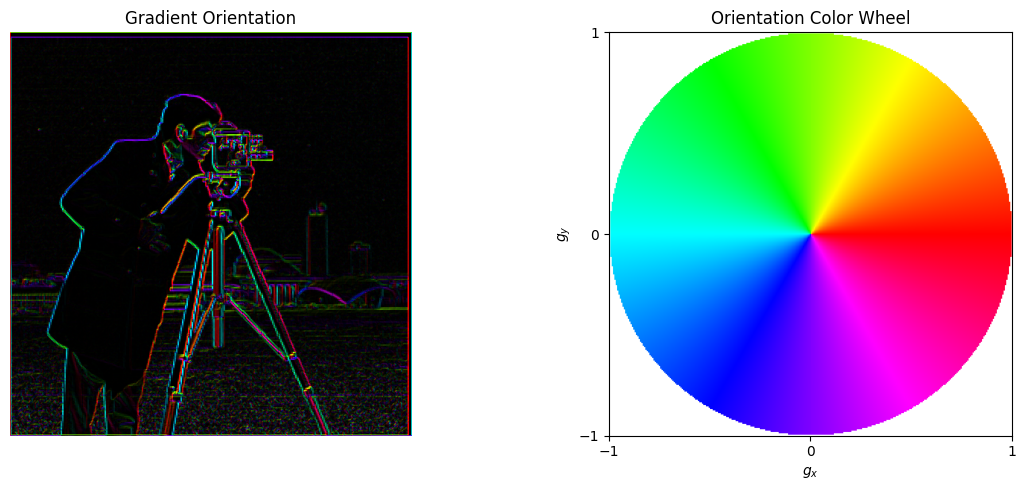

In [65]:
plt.figure(figsize=(12, 5))

# gradient orientation result
plt.subplot(1, 2, 1)
plt.imshow(orientation_rgb)
plt.title("Gradient Orientation")
plt.axis("off")

# orientation color wheel
plt.subplot(1, 2, 2)
plt.imshow(
    wheel_rgb,
    extent=[-1, 1, -1, 1],
    origin="lower"
)

plt.title("Orientation Color Wheel")
plt.xlabel("$g_x$")
plt.ylabel("$g_y$")

plt.xticks([-1, 0, 1])
plt.yticks([-1, 0, 1])

plt.tight_layout()
plt.show()

Gradient Orientation. For each pixel, the horizontal and vertical derivatives form a gradient vector \((g_x,g_y)\). Since built-in angle functions were not used, I estimated its orientation through a half-angle formulation. I first worked with the absolute gradient components and computed the gradient length \(r=\sqrt{g_x^2+g_y^2}\). The quantity \(t=|g_y|/(r+|g_x|)\) is equal to \(\tan(\theta/2)\), so the first-quadrant angle can be recovered as \(2\arctan(t)\). I approximated the remaining arctangent using its alternating Taylor expansion, with an additional argument transformation for values near one to improve convergence. The signs of the original gradient components were then used to place the angle back into the correct quadrant. For visualization, gradient direction controls hue while gradient magnitude controls brightness, so strong edges appear as bright colors and nearly flat regions remain dark.